### Knapsack Problem using Variational Quantum Eigensolver with Qiskit

This tutorial will walk you through solving the Knapsack problem, a classic optimization challenge, using a quantum algorithm called the Variational Quantum Eigensolver (VQE). We will use Qiskit to define the problem, convert it into a format suitable for a quantum computer, and then use VQE to find an approximate solution.

First, let's ensure Qiskit is installed and check the version.

In [1]:
import qiskit
print(qiskit.__version__)

2.5.2


### The Knapsack Problem

The Knapsack problem involves selecting a set of items, each with a specific weight and value, to maximize the total value without exceeding a given maximum weight capacity. It's a binary optimization problem: for each item, you either include it in the knapsack or you don't.

### Setting Up the Environment

Before we define the problem, we need to import the necessary libraries. These include:

- **Basic libraries:** numpy for numerical operations and matplotlib for plotting.

- **Qiskit Optimization:** Tools to define the Knapsack problem (Knapsack), convert it into a quadratic program, and map it to a quantum problem (QuadraticProgramToQubo).

- **Qiskit Algorithms:** The core VQE components, including the Estimator primitive for calculating expectation values and the EfficientSU2 ansatz.

- **SciPy:** A classical optimizer that VQE will use to minimize the cost function.

- **Qiskit Aer:** To simulate a quantum backend for our experiment.

In [2]:
# basic imports

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# quantum imports
from qiskit_optimization.applications import Maxcut, Knapsack
from qiskit.circuit import Parameter,QuantumCircuit
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.algorithms import CplexOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_optimization.algorithms import MinimumEigenOptimizer

# SciPy minimizer routine
from scipy.optimize import minimize
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit_aer import AerSimulator
backend = AerSimulator(method="automatic")


estimator = BackendEstimatorV2(backend=backend)
sampler = BackendSamplerV2(backend=backend)

### **Generate a Random Instance**

To make things interesting, let's create a random instance of the Knapsack problem. We'll define the number of items and generate random weights and values for each. The knapsack's capacity is set to 60% of the total weight of all items.

We then create a `Knapsack` object and convert it to a `QuadraticProgram`, which is a standard format for optimization problems.

In [3]:
# Set the random seed for reproducibility
np.random.seed(135)

# Use the same instance as part02/custom-penalty.ipynb
num_items = 6
weights = np.array([3, 5, 6, 7, 9, 10])
values = np.array([5, 10, 20, 30, 35, 40])
capacity = 14

print(f"Weights: {weights}")
print(f"Values: {values}")
print(f"Capacity: {capacity}")

# Create the Knapsack problem
knapsack = Knapsack(values.tolist(), weights.tolist(), capacity)

# Convert the problem to a QuadraticProgram
problem = knapsack.to_quadratic_program()
print(problem.prettyprint())



Weights: [ 3  5  6  7  9 10]
Values: [ 5 10 20 30 35 40]
Capacity: 14
Problem name: Knapsack

Maximize
  5*x_0 + 10*x_1 + 20*x_2 + 30*x_3 + 35*x_4 + 40*x_5

Subject to
  Linear constraints (1)
    3*x_0 + 5*x_1 + 6*x_2 + 7*x_3 + 9*x_4 + 10*x_5 <= 14  'c0'

  Binary variables (6)
    x_0 x_1 x_2 x_3 x_4 x_5



In [4]:
num_binary_vars_classical = problem.get_num_binary_vars()
print(f"Number of binary variables: {num_binary_vars_classical}")

Number of binary variables: 6


### **Finding the Exact Solution Classically**

Before turning to a quantum approach, let's find the exact solution using a classical optimizer. This will serve as our benchmark to see how well the VQE performs. We use the `CplexOptimizer` from Qiskit Optimization for this purpose. The solution `x` is a binary vector where `1` means an item is selected and `0` means it's left out.

In [5]:
# Solve the problem using CplexOptimizer
optimizer = CplexOptimizer()
result = optimizer.solve(problem)

result_classical = result
print(f"Optimal value: {result_classical.fval}, Solution vector: {result_classical.x}")


Optimal value: 50.0, Solution vector: [0. 0. 1. 1. 0. 0.]


### **From Quadratic Program to QUBO**

Quantum computers solve problems formulated as Hamiltonians. A common step is to first convert the problem into a **Quadratic Unconstrained Binary Optimization (QUBO)** problem. This format represents the problem as a single quadratic equation to be minimized, without any constraints.

The conversion automatically creates "slack" variables to transform the inequality constraint (total weight <= capacity) into an equality, which is then incorporated into the objective function with a penalty.

In [6]:
# problem to qubo
converter = QuadraticProgramToQubo()
qubo = converter.convert(problem)
print(qubo.export_as_lp_string())

C:\Users\monitsharma\AppData\Local\Temp\ipykernel_48224\1913652801.py:4: DeprecationWarning: The method ``qiskit_optimization.problems.quadratic_program.QuadraticProgram.export_as_lp_string()`` is deprecated as of Qiskit 0.7.0. It will be removed no earlier than 3 months after the release date. Use prettyprint instead.
  print(qubo.export_as_lp_string())


\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Knapsack

Minimize
 obj: - 11849 x_0 - 19750 x_1 - 23708 x_2 - 27666 x_3 - 35567 x_4 - 39520 x_5
      - 3948 c0@int_slack@0 - 7896 c0@int_slack@1 - 15792 c0@int_slack@2
      - 27636 c0@int_slack@3 + [ 2538 x_0^2 + 8460 x_0*x_1 + 10152 x_0*x_2
      + 11844 x_0*x_3 + 15228 x_0*x_4 + 16920 x_0*x_5 + 1692 x_0*c0@int_slack@0
      + 3384 x_0*c0@int_slack@1 + 6768 x_0*c0@int_slack@2
      + 11844 x_0*c0@int_slack@3 + 7050 x_1^2 + 16920 x_1*x_2 + 19740 x_1*x_3
      + 25380 x_1*x_4 + 28200 x_1*x_5 + 2820 x_1*c0@int_slack@0
      + 5640 x_1*c0@int_slack@1 + 11280 x_1*c0@int_slack@2
      + 19740 x_1*c0@int_slack@3 + 10152 x_2^2 + 23688 x_2*x_3 + 30456 x_2*x_4
      + 33840 x_2*x_5 + 3384 x_2*c0@int_slack@0 + 6768 x_2*c0@int_slack@1
      + 13536 x_2*c0@int_slack@2 + 23688 x_2*c0@int_slack@3 + 13818 x_3^2
      + 35532 x_3*x_4 + 39480 x_3*x_5 + 3948 x_3*c0@int_slack@0
      + 7896 x_3*c0@int_slack@1 + 15792 x_3*c0

As you can see, the QUBO has more variables than the original `num_items` because of the slack variables introduced to handle the weight constraint. Let's check the new number of variables.

In [7]:
num_vars = qubo.get_num_vars()
print(f"Number of variables in QUBO: {num_vars}")
print(f"Number of variables in classical formulation: {num_binary_vars_classical}")
increase = num_vars - num_binary_vars_classical
percent_increase = (increase / num_binary_vars_classical) * 100
print(f"Number of variables increased by {increase} ({percent_increase:.1f}%) when converting to QUBO (due to slack variables for constraints).")

Number of variables in QUBO: 10
Number of variables in classical formulation: 6
Number of variables increased by 4 (66.7%) when converting to QUBO (due to slack variables for constraints).


### **Mapping the QUBO to an Ising Hamiltonian**

The VQE algorithm works by finding the minimum energy (eigenvalue) of a Hamiltonian. We now convert our QUBO problem into an **Ising Hamiltonian**. This Hamiltonian is an operator that can be measured on a quantum computer. Each binary variable in the QUBO is mapped to a qubit.

The conversion gives us two components:

- `qubitOp`: The Ising Hamiltonian, represented as a sum of Pauli operators (Z, ZZ).

- `offset`: A constant energy shift that we'll add back to our final result.

In [8]:
qubitOp, offset = qubo.to_ising()
print("Offset:", offset)
print("Ising Hamiltonian:")
print(str(qubitOp))

Offset: 36801.5
Ising Hamiltonian:
SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIZII', 'IIIIIIZIII', 'IIIIIZIIII', 'IIIIZIIIII', 'IIIZIIIIII', 'IIZIIIIIII', 'IZIIIIIIII', 'ZIIIIIIIII', 'IIIIIIIIZZ', 'IIIIIIIZIZ', 'IIIIIIZIIZ', 'IIIIIZIIIZ', 'IIIIZIIIIZ', 'IIIZIIIIIZ', 'IIZIIIIIIZ', 'IZIIIIIIIZ', 'ZIIIIIIIIZ', 'IIIIIIIZZI', 'IIIIIIZIZI', 'IIIIIZIIZI', 'IIIIZIIIZI', 'IIIZIIIIZI', 'IIZIIIIIZI', 'IZIIIIIIZI', 'ZIIIIIIIZI', 'IIIIIIZZII', 'IIIIIZIZII', 'IIIIZIIZII', 'IIIZIIIZII', 'IIZIIIIZII', 'IZIIIIIZII', 'ZIIIIIIZII', 'IIIIIZZIII', 'IIIIZIZIII', 'IIIZIIZIII', 'IIZIIIZIII', 'IZIIIIZIII', 'ZIIIIIZIII', 'IIIIZZIIII', 'IIIZIZIIII', 'IIZIIZIIII', 'IZIIIZIIII', 'ZIIIIZIIII', 'IIIZZIIIII', 'IIZIZIIIII', 'IZIIZIIIII', 'ZIIIZIIIII', 'IIZZIIIIII', 'IZIZIIIIII', 'ZIIZIIIIII', 'IZZIIIIIII', 'ZIZIIIIIII', 'ZZIIIIIIII'],
              coeffs=[ -5496.5+0.j,  -9160. +0.j, -10988. +0.j, -12816. +0.j, -16479.5+0.j,
 -18310. +0.j,  -1833. +0.j,  -3666. +0.j,  -7332. +0.j, -12831. +0.j,
   1057.5+0.j,  

### **The Variational Quantum Eigensolver (VQE)**

VQE is a hybrid quantum-classical algorithm. It uses a quantum computer to prepare a trial wavefunction (using a parameterized circuit called an **ansatz**) and measure the energy of the Hamiltonian. A classical computer then takes this energy and adjusts the parameters of the ansatz to find a new trial state with lower energy. This process is repeated until the minimum energy is found.

#### **The Ansatz**

The ansatz is a parameterized quantum circuit that creates the trial ground state. Its structure is crucial for the success of VQE. A good ansatz should be able to prepare the true ground state of the Hamiltonian. Here, we use `EfficientSU2`, a versatile and commonly used hardware-efficient ansatz from the Qiskit circuit library.


Let's visualize the structure of our ansatz circuit.

C:\Users\monitsharma\AppData\Local\Temp\ipykernel_48224\4079246929.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(qubitOp.num_qubits, reps=reps, entanglement='linear', insert_barriers=True)  # change the entanglement strategy as needed ('full', 'linear', 'circular', etc.)


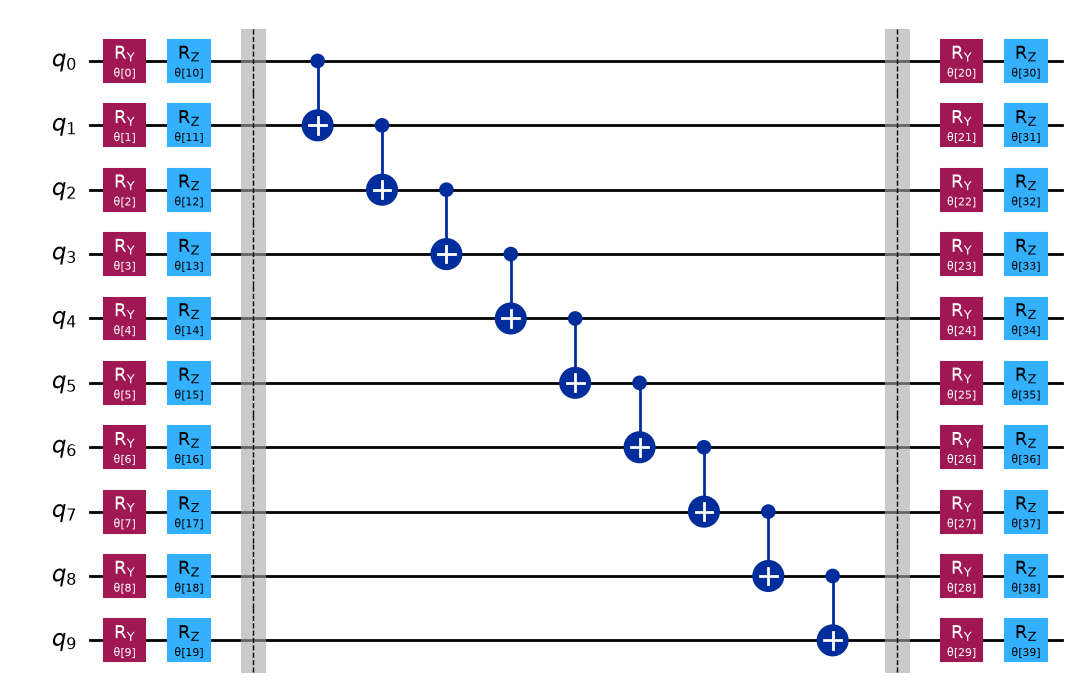

In [9]:
reps = 1 # number of repetitions for the ansatz
ansatz = EfficientSU2(qubitOp.num_qubits, reps=reps, entanglement='linear', insert_barriers=True)  # change the entanglement strategy as needed ('full', 'linear', 'circular', etc.)
ansatz.decompose().draw("mpl", style="iqp")

The classical optimizer needs to tune the parameters of this ansatz. The number of parameters determines the complexity of the classical optimization task.

In [10]:
num_params = ansatz.num_parameters
print(f"The ansatz has {num_params} trainable parameters for {ansatz.num_qubits} qubits (problem variables + slack variables).")

The ansatz has 40 trainable parameters for 10 qubits (problem variables + slack variables).


#### **Executing the VQE Algorithm**

Now we set up and run the VQE algorithm.

- **Cost Function:** We define a `cost_func` that takes the ansatz parameters, builds the circuit, and uses the `Estimator` primitive to calculate the expectation value (energy) of our Hamiltonian. This function returns the energy, which the classical optimizer will try to minimize. We also include a dictionary, `cost_history_dict`, to store the energy at each iteration so we can plot the convergence later.

- **Initial Parameters:** We start the optimization from a random initial set of parameters, `x0`.

- **Classical Optimizer:** We use the `COBYLA` optimizer from `scipy.optimize.minimize` to find the optimal parameters for our ansatz. This optimizer repeatedly calls our `cost_func` to find the parameter values that result in the lowest energy.

In [11]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

This dictionary will store the history of our optimization process.

In [12]:
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

Let's generate the random starting point for the optimizer

In [13]:
# Fixed initial point for a reproducible and stronger local optimum
np.random.seed(0)
x0 = 2 * np.pi * np.random.random(num_params)
x0

array([3.44829694, 4.49366732, 3.78727399, 3.42360201, 2.66190161,
       4.0582724 , 2.74944154, 5.60317502, 6.0548717 , 2.40923412,
       4.97455513, 3.32314479, 3.56912924, 5.8156952 , 0.44633272,
       0.54744954, 0.12703594, 5.23150478, 4.88930306, 5.46644755,
       6.14884039, 5.02126135, 2.89956035, 4.90420945, 0.74314013,
       4.02074236, 0.90071527, 5.93552986, 3.27886971, 2.60539781,
       1.66225193, 4.86465374, 2.86607707, 3.57157584, 0.1180598 ,
       3.88071828, 3.84591085, 3.87631062, 5.92974406, 4.28400329])

Now, we run the classical optimizer. It will print the cost at each iteration, giving us a live view of the VQE's progress as it searches for the minimum energy.

In [14]:
ansatz = ansatz.decompose()

res = minimize(
        cost_func,
        x0,
        args=(ansatz, qubitOp, estimator),
        method="cobyla", # You can change the method to 'nelder-mead', 'bfgs', etc. as needed
        options={"maxiter": 1000, "disp": True, "rhobeg": 0.1, "tol": 1e-6}  # also can adjust the options like 'maxiter', 'disp', 'rhobeg', 'tol' as needed
    )

Iters. done: 1 [Current cost: 2073.94677734375]
Iters. done: 2 [Current cost: 1903.307373046875]
Iters. done: 3 [Current cost: 1046.504150390625]
Iters. done: 4 [Current cost: -212.712890625]
Iters. done: 5 [Current cost: 723.79248046875]
Iters. done: 6 [Current cost: 322.71142578125]
Iters. done: 7 [Current cost: 349.892578125]
Iters. done: 8 [Current cost: -387.158203125]
Iters. done: 9 [Current cost: 105.543701171875]
Iters. done: 10 [Current cost: 769.076171875]
Iters. done: 11 [Current cost: -411.2216796875]
Iters. done: 12 [Current cost: -793.0859375]
Iters. done: 13 [Current cost: -568.08154296875]
Iters. done: 14 [Current cost: -902.376953125]
Iters. done: 15 [Current cost: -410.15478515625]
Iters. done: 16 [Current cost: -534.900634765625]
Iters. done: 17 [Current cost: -422.43798828125]
Iters. done: 18 [Current cost: -658.30712890625]
Iters. done: 19 [Current cost: -1052.82666015625]
Iters. done: 20 [Current cost: -895.124755859375]
Iters. done: 21 [Current cost: -995.2238769

The optimizer has successfully terminated. The `res` object contains the results, including the final minimized energy (`fun`) and the optimal parameters (`x`).

In [15]:
res

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -3152.713623046875
       x: [ 3.548e+00  4.594e+00 ...  5.930e+00  4.284e+00]
    nfev: 394
   maxcv: 0.0

### **Post-Processing: Analyzing the Results**

Let's analyze the outcome of our VQE run. First, we can confirm that the final parameters from the optimizer match what we stored in our history dictionary.

In [16]:
all(cost_history_dict["prev_vector"] == res.x)


False

Now, let's plot the cost (energy) against the number of iterations. This convergence plot shows how the VQE algorithm progressively found lower energy states until it converged on a solution.

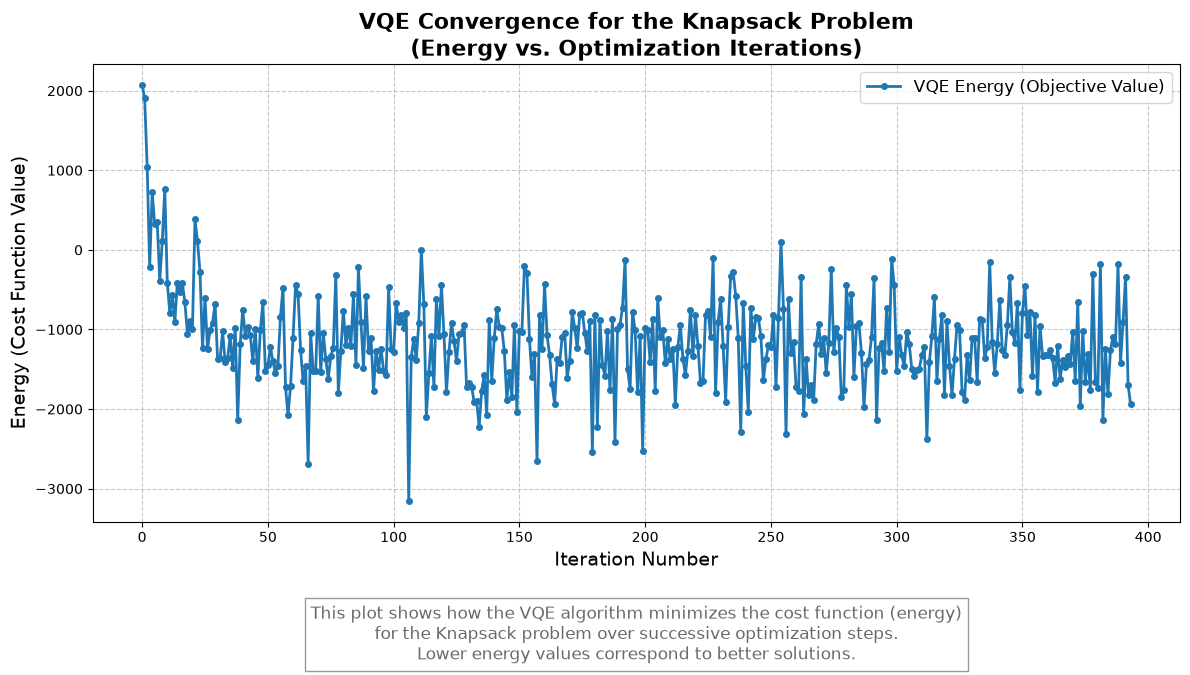

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))  # Bigger figure

ax.plot(
    range(cost_history_dict["iters"]),
    cost_history_dict["cost_history"],
    color="tab:blue",
    linewidth=2,
    marker="o",
    markersize=4,
    label="VQE Energy (Objective Value)"
)

# Add annotations and explanations
ax.set_xlabel("Iteration Number", fontsize=14)
ax.set_ylabel("Energy (Cost Function Value)", fontsize=14)
ax.set_title("VQE Convergence for the Knapsack Problem\n(Energy vs. Optimization Iterations)", fontsize=16, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.7)
ax.legend(fontsize=12)

# Add a text box explaining the plot
explanation = (
    "This plot shows how the VQE algorithm minimizes the cost function (energy)\n"
    "for the Knapsack problem over successive optimization steps.\n"
    "Lower energy values correspond to better solutions."
)
ax.text(
    0.5, -0.18, explanation,
    fontsize=12, color="dimgray", ha="center", va="top", transform=ax.transAxes,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.tight_layout()
plt.show()

### Run the Optimized Circuit and Sample the Solution

The VQE optimization has given us the best parameters for our ansatz. We now plug these parameters into the circuit to prepare the approximate ground state of our Hamiltonian.

Since the goal is to find the solution bitstring, we add measurements to all qubits and use the `Sampler` primitive to run the circuit many times (e.g., 10,000 "shots") and collect the measurement outcomes.

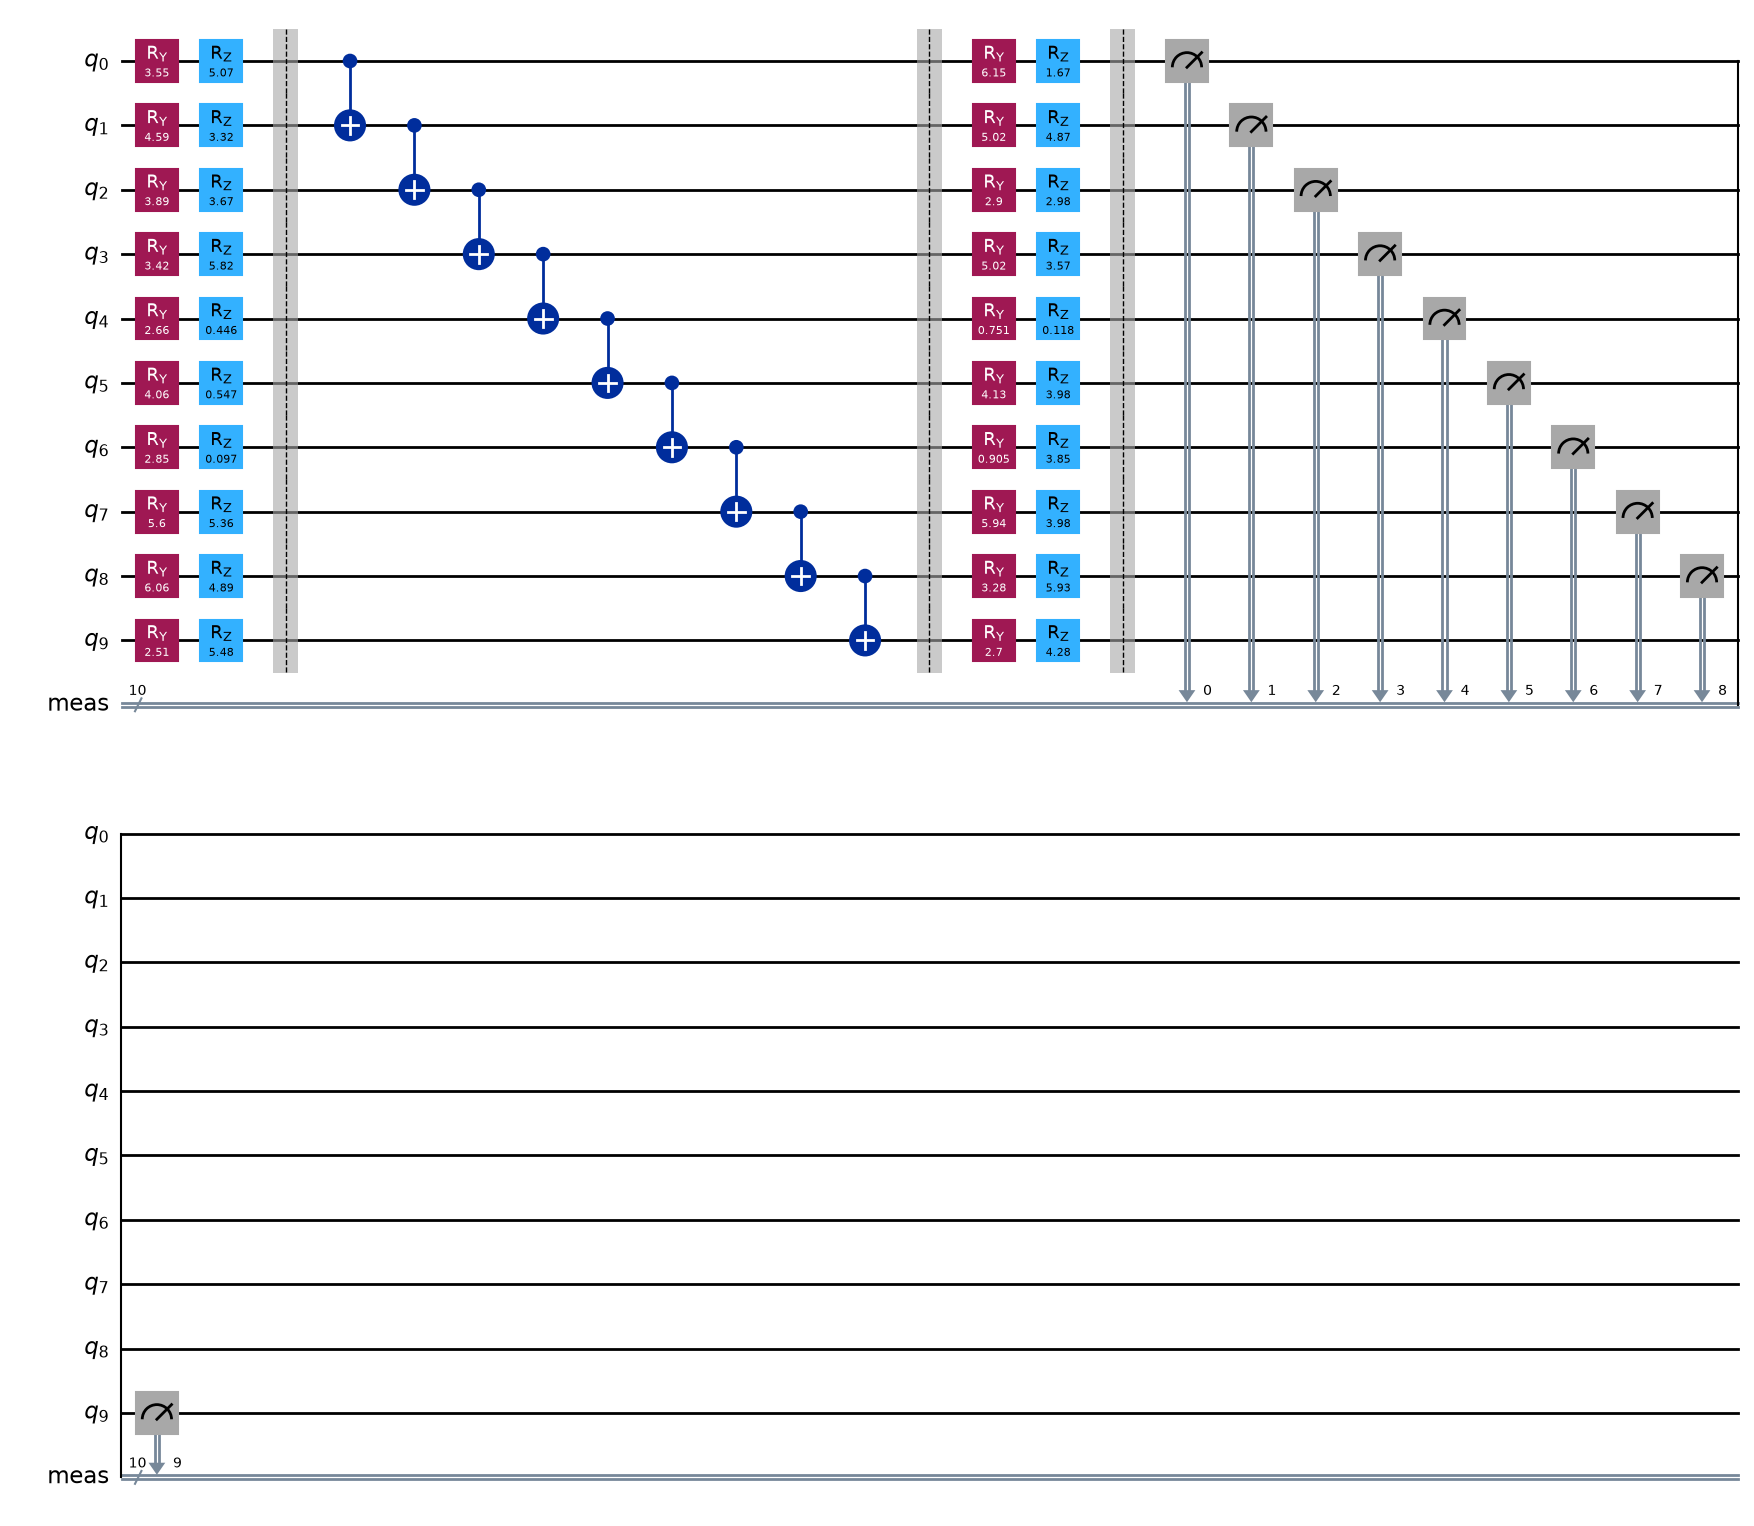

In [18]:
ansatz = ansatz.assign_parameters(res.x)
ansatz.measure_all()
ansatz.draw("mpl", style="iqp")

In [19]:
pub = (ansatz,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}

The output of the sampler is a probability distribution over all possible measurement outcomes (bitstrings). The bitstring with the highest probability is our candidate for the optimal solution.

In [20]:
# Select the highest-value feasible sample, rather than blindly using
# the most frequent raw bitstring (which may be infeasible).
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
feasible_candidates = []
for key, probability in final_distribution_int.items():
    candidate_bitstring = to_bitstring(key, num_vars)
    candidate_bitstring.reverse()
    candidate_solution = converter.interpret(candidate_bitstring)
    if problem.get_feasibility_info(candidate_solution)[0]:
        candidate_value = problem.objective.evaluate(candidate_solution)
        feasible_candidates.append((candidate_value, probability, candidate_bitstring))

if feasible_candidates:
    _, _, most_likely_bitstring = max(feasible_candidates, key=lambda row: (row[0], row[1]))
else:
    most_likely = keys[np.argmax(np.abs(values))]
    most_likely_bitstring = to_bitstring(most_likely, num_vars)
    most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 0, 1, 1, 0, 0, 0, 0, 1, 0]


In [21]:
result = converter.interpret(most_likely_bitstring)
cost = problem.objective.evaluate(result)
feasible =problem.get_feasibility_info(result)[0]


print("Result knapsack:", result)
print("Result value:", cost)
print("Feasible:", feasible)

Result knapsack: [0. 0. 1. 1. 0. 0.]
Result value: 50.0
Feasible: True


In [22]:
print("="*40)
print("🔎 Best Known Classical Solution")
print("="*40)
print(f"  • Total Value:        {result_classical.fval}")
print(f"  • Solution Vector:    {result_classical.x}")
print()

print("="*40)
print("⚛️  VQE (Quantum) Solution")
print("="*40)
print(f"  • Total Value:        {cost}")
print(f"  • Solution Vector:    {result}")
print(f"  • Feasible:           {feasible}")

if feasible:
    optimality_gap = 100 * (result_classical.fval - cost) / result_classical.fval
    print(f"  • Optimality Gap:     {optimality_gap:.2f}%")
else:
    print("  • Note: Quantum solution is not feasible.")

print("\n" + "-"*40)
if feasible:
    if abs(cost - result_classical.fval) < 1e-6:
        print("✅ Quantum solution matches the classical optimum!")
    else:
        print("ℹ️  Quantum solution is suboptimal compared to classical.")
else:
    print("❌ Quantum solution is not feasible.")
print("-"*40)

🔎 Best Known Classical Solution
  • Total Value:        50.0
  • Solution Vector:    [0. 0. 1. 1. 0. 0.]

⚛️  VQE (Quantum) Solution
  • Total Value:        50.0
  • Solution Vector:    [0. 0. 1. 1. 0. 0.]
  • Feasible:           True
  • Optimality Gap:     0.00%

----------------------------------------
✅ Quantum solution matches the classical optimum!
----------------------------------------
